# AgroPredict — Módulo 3: Modelos de Inteligencia Artificial (Machine Learning)

Este notebook toma los datos generados en el Módulo 2 (`maiz_clima_modelo.csv`) que ya integran la producción de maíz con las variables climáticas de NASA POWER.

**Pasos:**
1. Cargar el dataset final y tratar valores nulos.
2. Codificar las variables categóricas (One-Hot Encoding).
3. Separar los datos cronológicamente (Entrenamiento 2006-2016 y Validación 2017-2018) para evitar filtración de datos del futuro (data leakage).
4. Entrenar modelos de regresión (Random Forest Regressor y Gradient Boosting).
5. Evaluar los modelos (RMSE, MAE).
6. Analizar la importancia de las variables (Feature Importance).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# === RUTAS ===
RUTA_DATOS = "../data/maiz_clima_modelo.csv"

print("Librerías importadas correctamente.")

Matplotlib is building the font cache; this may take a moment.


Librerías importadas correctamente.


## 1. Cargar y Explorar el Dataset

In [4]:
# Leer los datos (asegurando de leer cod_dep y cod_mun como str para no perder los 0s)
try:
    df = pd.read_csv(RUTA_DATOS, dtype={'cod_dep': str, 'cod_mun': str})
    print(f"Dataset cargado. Dimensiones: {df.shape}")
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo en {RUTA_DATOS}.")
    print("Asegúrate de haber ejecutado completamente el Notebook 02.")
    df = pd.DataFrame() # Para evitar errores en las siguientes celdas

Dataset cargado. Dimensiones: (24898, 21)


In [6]:
if not df.empty:
    display(df.head())
    
    # Revisar valores nulos
    print("\nValores Nulos por columna:")
    display(df.isnull().sum())

,cod_dep,departamento,cod_mun,municipio,cultivo,desagregacion,ciclo_cultivo,anio,periodo,semestre,...,area_cosechada_ha,produccion_t,rendimiento_tha,precip_total_mm,precip_dias_lluvia,temp_media_c,temp_max_media_c,temp_min_media_c,radiacion_media,humedad_media_pct
0,05,ANTIOQUIA,05051,ARBOLETES,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,...,4650,11625,2.5,953.23,131,26.532663,30.451141,24.023859,17.327228,87.672065
1,05,ANTIOQUIA,05101,CIUDAD BOLIVAR,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,...,450,1350,3.0,1736.69,137,20.486141,23.837772,18.154837,15.186739,91.523587
2,05,ANTIOQUIA,05842,URAMITA,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,...,180,630,3.5,1373.35,130,20.685217,23.987120,18.252120,15.667554,90.606304
3,05,ANTIOQUIA,05380,LA ESTRELLA,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,...,3,12,4.0,1222.41,126,17.470326,21.399185,14.517717,18.047935,88.248207
4,13,BOLIVAR,13442,MARIA LA BAJA,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,...,2030,7105,3.5,1059.28,141,28.067446,30.757609,26.476250,18.069130,82.464565



Valores Nulos por columna:


cod_dep               0
departamento          0
cod_mun               0
municipio             0
cultivo               0
desagregacion         0
ciclo_cultivo         0
anio                  0
periodo               0
semestre              0
area_sembrada_ha      0
area_cosechada_ha     0
produccion_t          0
rendimiento_tha       0
precip_total_mm       0
precip_dias_lluvia    0
temp_media_c          0
temp_max_media_c      0
temp_min_media_c      0
radiacion_media       0
humedad_media_pct     0
dtype: int64

### 1.1 Tratamiento de valores nulos
Es probable que haya municipios para los cuales NASA POWER no devolvió datos climáticos. Para el modelo, eliminaremos esas filas, ya que el clima es fundamental para la predicción.

In [14]:
if not df.empty:
    df_modelo = df.dropna(subset=['precip_total_mm']).copy()
    print(f"Dimensiones después de eliminar nulos climáticos: {df_modelo.shape}")
    
    # También podemos eliminar columnas que no son útiles para la predicción en sí, 
    # como 'municipio' y 'departamento' (ya que usaremos los códigos o regiones)
    # y 'area_sembrada_ha', 'area_cosechada_ha', 'produccion_t' ya que nuestro objetivo directo es 'rendimiento_tha'.
    cols_a_eliminar = ['municipio', 'departamento', 'area_sembrada_ha', 'area_cosechada_ha', 'produccion_t', 'cultivo', 'ciclo_cultivo', 'periodo']
    df_modelo = df_modelo.drop(columns=[c for c in cols_a_eliminar if c in df_modelo.columns])

Dimensiones después de eliminar nulos climáticos: (24898, 21)


## 2. Codificación de Variables Categóricas (One-Hot Encoding)
Los modelos matemáticos requieren números, no texto. Convertiremos el tipo de desagregación, el semestre, y opcionalmente el departamento en columnas binarias (0 y 1).

In [15]:
if not df.empty:
    # Variables a codificar
    # Nota: No codificamos 'cod_mun' porque generaría más de 1000 columnas y puede causar overfitting. 
    # Usaremos 'cod_dep' (32 departamentos) para dar contexto regional.
    cat_cols = ['cod_dep', 'desagregacion', 'semestre']
    
    # Aplicar One-Hot Encoding
    df_encoded = pd.get_dummies(df_modelo, columns=[c for c in cat_cols if c in df_modelo.columns], drop_first=True)
    
    print(f"Dimensiones después de codificar: {df_encoded.shape}")
    display(df_encoded.head())

Dimensiones después de codificar: (24898, 43)


,cod_mun,anio,rendimiento_tha,precip_total_mm,precip_dias_lluvia,temp_media_c,temp_max_media_c,temp_min_media_c,radiacion_media,humedad_media_pct,...,cod_dep_85,cod_dep_86,cod_dep_88,cod_dep_91,cod_dep_94,cod_dep_95,cod_dep_97,cod_dep_99,desagregacion_MAIZ TRADICIONAL,semestre_B
0,05051,2006,2.5,953.23,131,26.532663,30.451141,24.023859,17.327228,87.672065,...,False,False,False,False,False,False,False,False,False,True
1,05101,2006,3.0,1736.69,137,20.486141,23.837772,18.154837,15.186739,91.523587,...,False,False,False,False,False,False,False,False,False,True
2,05842,2006,3.5,1373.35,130,20.685217,23.987120,18.252120,15.667554,90.606304,...,False,False,False,False,False,False,False,False,False,True
3,05380,2006,4.0,1222.41,126,17.470326,21.399185,14.517717,18.047935,88.248207,...,False,False,False,False,False,False,False,False,False,True
4,13442,2006,3.5,1059.28,141,28.067446,30.757609,26.476250,18.069130,82.464565,...,False,False,False,False,False,False,False,False,False,True


## 3. Separación de Datos (Train / Test Split)
Como los datos tienen una fuerte componente temporal, **NO** debemos hacer una división aleatoria (random split). Podríamos entrenar el modelo con datos de 2017 y pedirle predecir 2016, lo cual no es realista.
Dividiremos **cronológicamente**:
- **Train (Entrenamiento):** <= 2016
- **Test (Prueba):** >= 2017

In [16]:
if not df.empty:
    año_corte = 2016
    
    # Separar predictores (X) y variable objetivo (y)
    X = df_encoded.drop(columns=['rendimiento_tha', 'cod_mun'])
    y = df_encoded['rendimiento_tha']
    
    # Máscaras
    train_mask = X['anio'] <= año_corte
    test_mask = X['anio'] > año_corte
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    
    print(f"Tamaño de Entrenamiento (<= {año_corte}): {X_train.shape[0]} filas")
    print(f"Tamaño de Prueba (> {año_corte}): {X_test.shape[0]} filas")

Tamaño de Entrenamiento (<= 2016): 21651 filas
Tamaño de Prueba (> 2016): 3247 filas


## 4. Entrenamiento de Modelos
Entrenaremos dos modelos populares para datos tabulares: **Random Forest** y **Gradient Boosting**.

In [17]:
if not df.empty:
    print("Entrenando Random Forest Regressor...")
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    print("Random Forest entrenado exitosamente.")
    
    print("\nEntrenando Gradient Boosting Regressor...")
    gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
    gb_model.fit(X_train, y_train)
    print("Gradient Boosting entrenado exitosamente.")

Entrenando Random Forest Regressor...
Random Forest entrenado exitosamente.

Entrenando Gradient Boosting Regressor...
Gradient Boosting entrenado exitosamente.


## 5. Evaluación de los Modelos
Usaremos las siguientes métricas:
- **RMSE (Root Mean Squared Error):** Raíz del error cuadrático medio. Penaliza errores grandes.
- **MAE (Mean Absolute Error):** Error absoluto medio. Cuántas toneladas por hectárea nos equivocamos en promedio.
- **R2 Score:** Qué porcentaje de la variabilidad del rendimiento es explicada por nuestro modelo.

In [19]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    preds = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    print(f"--- Rendimiento: {nombre} ---")
    print(f"RMSE: {rmse:.3f} t/ha")
    print(f"MAE:  {mae:.3f} t/ha")
    print(f"R2:   {r2:.3f}\n")
    return preds

if not df.empty:
    rf_preds = evaluar_modelo("Random Forest", rf_model, X_test, y_test)
    gb_preds = evaluar_modelo("Gradient Boosting", gb_model, X_test, y_test)

--- Rendimiento: Random Forest ---
RMSE: 0.755 t/ha
MAE:  0.545 t/ha
R2:   0.711

--- Rendimiento: Gradient Boosting ---
RMSE: 0.707 t/ha
MAE:  0.510 t/ha
R2:   0.747



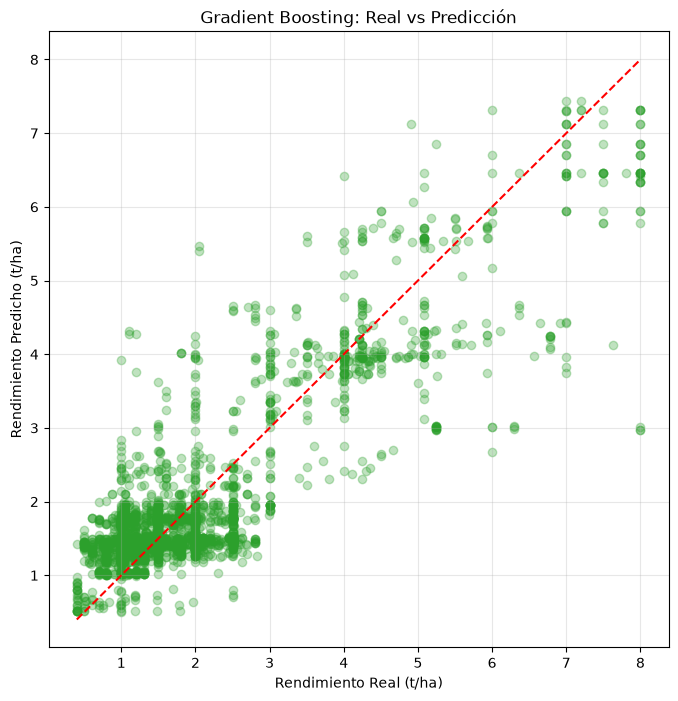

In [20]:
# Gráfico de Predicciones vs Realidad (Para Gradient Boosting)
if not df.empty:
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, gb_preds, alpha=0.3, color='#2ca02c')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Rendimiento Real (t/ha)')
    plt.ylabel('Rendimiento Predicho (t/ha)')
    plt.title('Gradient Boosting: Real vs Predicción')
    plt.show()

## 6. Importancia de Variables (Feature Importance)
Veamos qué variables fueron las más importantes para el modelo al momento de predecir el rendimiento del maíz.

/var/folders/b9/xfrl_kfx643dw38bws00pk_r0000gn/T/ipykernel_15124/1423185.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15, x='Importancia', y='Variable', palette='viridis')


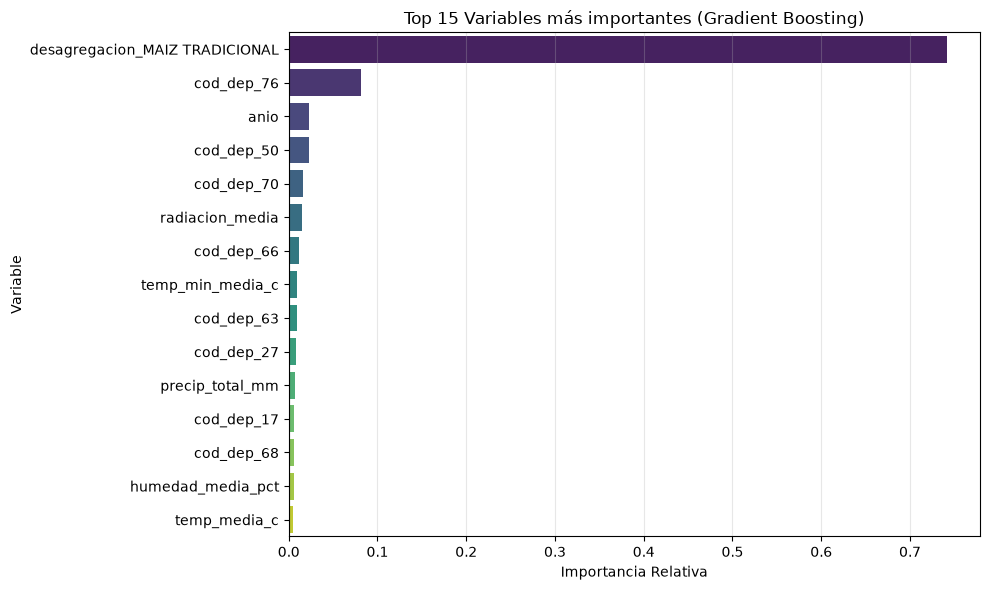

In [21]:
if not df.empty:
    # Obtenemos la importancia de Gradient Boosting
    importancias = gb_model.feature_importances_
    
    # Creamos un DataFrame para visualizar
    df_imp = pd.DataFrame({
        'Variable': X_train.columns,
        'Importancia': importancias
    }).sort_values(by='Importancia', ascending=False)
    
    # Mostramos las 15 más importantes
    top_15 = df_imp.head(15)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_15, x='Importancia', y='Variable', palette='viridis')
    plt.title('Top 15 Variables más importantes (Gradient Boosting)')
    plt.xlabel('Importancia Relativa')
    plt.ylabel('Variable')
    plt.tight_layout()
    plt.show()